In [1]:
import pandas as pd
import numpy as np
from sklearn import *
import matplotlib.pyplot as plt

In [89]:
df = pd.read_csv("https://raw.githubusercontent.com/abulbasar/data/master/credit-default.csv")

In [3]:
df

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,unknown,12,repaid,furniture,1736,< 100 DM,4 - 7 yrs,3,female,none,...,real estate,31,none,own,1,1,1,none,yes,unskilled resident
996,< 0 DM,30,repaid,car (used),3857,< 100 DM,1 - 4 yrs,4,divorced male,none,...,building society savings,40,none,own,1,1,1,yes,yes,mangement self-employed
997,unknown,12,repaid,radio/tv,804,< 100 DM,> 7 yrs,4,single male,none,...,other,38,none,own,1,1,1,none,yes,skilled employee
998,< 0 DM,45,repaid,radio/tv,1845,< 100 DM,1 - 4 yrs,4,single male,none,...,unknown/none,23,none,for free,1,2,1,yes,yes,skilled employee


In [4]:
df["default"].value_counts()

1    700
2    300
Name: default, dtype: int64

In [5]:
df["default"].value_counts()/len(df) #1: customer is not defaulted. 2: customer was defaulted

1    0.7
2    0.3
Name: default, dtype: float64

In [6]:
target = "default"
X = df.drop(columns = target)
X = pd.get_dummies(X, drop_first=True)

label_encoder = preprocessing.LabelEncoder()
y = df[target]
y = label_encoder.fit_transform(y)

X

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,dependents,checking_balance_< 0 DM,checking_balance_> 200 DM,checking_balance_unknown,...,property_unknown/none,installment_plan_none,installment_plan_stores,housing_own,housing_rent,telephone_yes,foreign_worker_yes,job_skilled employee,job_unemployed non-resident,job_unskilled resident
0,6,1169,4,4,67,2,1,1,0,0,...,0,1,0,1,0,1,1,1,0,0
1,48,5951,2,2,22,1,1,0,0,0,...,0,1,0,1,0,0,1,1,0,0
2,12,2096,2,3,49,1,2,0,0,1,...,0,1,0,1,0,0,1,0,0,1
3,42,7882,2,4,45,1,2,1,0,0,...,0,1,0,0,0,0,1,1,0,0
4,24,4870,3,4,53,2,2,1,0,0,...,1,1,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,12,1736,3,4,31,1,1,0,0,1,...,0,1,0,1,0,0,1,0,0,1
996,30,3857,4,4,40,1,1,1,0,0,...,0,1,0,1,0,1,1,0,0,0
997,12,804,4,4,38,1,1,0,0,1,...,0,1,0,1,0,0,1,1,0,0
998,45,1845,4,4,23,1,1,1,0,0,...,1,1,0,0,0,1,1,1,0,0


In [7]:
y

array([0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,

In [8]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.LogisticRegression())
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)


In [9]:
y_train_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,

In [10]:
y_test_pred

array([1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0])

In [11]:
states = []
for i in range(len(y_test)):
    t = y_test[i]
    p = y_test_pred[i]
    if t == p:
        state = "TP" if p == 1 else "TN"
    else: 
        state = "FP" if p == 1 else "FN"
    states.append(state)
        
    
    
pd.DataFrame({"actual": y_test, "prediction": y_test_pred, "state": states})

,actual,prediction,state
0,1,1,TP
1,1,0,FN
2,0,0,TN
3,1,1,TP
4,0,0,TN
...,...,...,...
295,1,1,TP
296,1,0,FN
297,0,1,FP
298,0,1,FP


In [12]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[168,  32],
       [ 42,  58]])

In [13]:
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       200
           1       0.64      0.58      0.61       100

    accuracy                           0.75       300
   macro avg       0.72      0.71      0.72       300
weighted avg       0.75      0.75      0.75       300



In [14]:
pd.Series(y_test).value_counts()/len(y_test)

0    0.666667
1    0.333333
dtype: float64

In [15]:
baseline_accuracy = 0.66

In [16]:
y_train_prob = pipe.predict_proba(X_train)[:, 1]
y_test_prob = pipe.predict_proba(X_test)[:, 1]

In [17]:
threshold = 0.5
y_test_pred = np.where(y_test_prob>threshold, 1, 0)
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       200
           1       0.64      0.58      0.61       100

    accuracy                           0.75       300
   macro avg       0.72      0.71      0.72       300
weighted avg       0.75      0.75      0.75       300



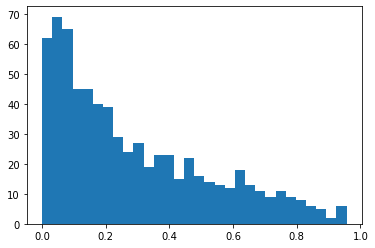

In [21]:
plt.hist(y_train_prob, bins = 30);

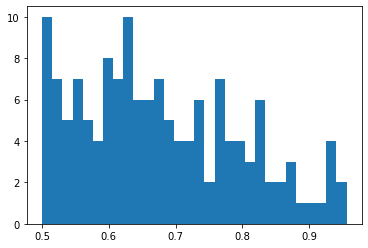

In [28]:
plt.hist(y_train_prob[y_train_pred == 1], bins = 30);

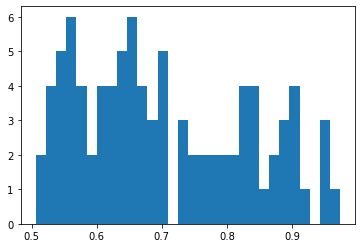

In [29]:
plt.hist(y_test_prob[y_test_pred == 1], bins = 30);

In [18]:
pipe.predict_proba(X_test)

array([[1.44463062e-01, 8.55536938e-01],
       [9.90574348e-01, 9.42565192e-03],
       [6.71637950e-01, 3.28362050e-01],
       [3.42452090e-01, 6.57547910e-01],
       [9.46761846e-01, 5.32381540e-02],
       [7.48109672e-01, 2.51890328e-01],
       [5.90088293e-01, 4.09911707e-01],
       [5.57835877e-01, 4.42164123e-01],
       [5.56832450e-02, 9.44316755e-01],
       [7.04333597e-01, 2.95666403e-01],
       [8.58401474e-01, 1.41598526e-01],
       [2.42027293e-01, 7.57972707e-01],
       [9.99453650e-01, 5.46349574e-04],
       [1.13196885e-01, 8.86803115e-01],
       [9.69183132e-01, 3.08168683e-02],
       [9.44887940e-01, 5.51120600e-02],
       [3.46881876e-01, 6.53118124e-01],
       [4.47951804e-01, 5.52048196e-01],
       [7.50142282e-02, 9.24985772e-01],
       [3.39193268e-01, 6.60806732e-01],
       [8.77182794e-01, 1.22817206e-01],
       [9.70958216e-01, 2.90417837e-02],
       [1.51735050e-01, 8.48264950e-01],
       [3.04424689e-01, 6.95575311e-01],
       [7.370714

In [36]:
threshold = 0.2
y_test_pred = np.where(y_test_prob>threshold, 1, 0)
print(metrics.confusion_matrix(y_test, y_test_pred))

[[118  82]
 [ 12  88]]


In [37]:
threshold = 0.5
y_test_pred = np.where(y_test_prob>threshold, 1, 0)
print(metrics.confusion_matrix(y_test, y_test_pred))

[[168  32]
 [ 42  58]]


In [38]:
threshold = 0.8
y_test_pred = np.where(y_test_prob>threshold, 1, 0)
print(metrics.confusion_matrix(y_test, y_test_pred))

[[195   5]
 [ 80  20]]


In [41]:
X_test.amount[(y_test==0) & (y_test_pred == 0)].sum()

613329

In [42]:
X_test.amount[(y_test==1) & (y_test_pred == 0)].sum()

290265

In [49]:
threshold = 0.37
y_test_pred = np.where(y_test_prob>threshold, 1, 0)
tn_amount = X_test.amount[(y_test==0) & (y_test_pred == 0)].sum()
fn_amount = X_test.amount[(y_test==1) & (y_test_pred == 0)].sum()
fn_amount/tn_amount

0.1888298431459572

Text(0.5, 1.0, 'ROC curve, auc: 0.820')

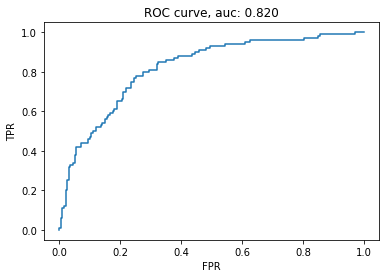

In [58]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")

auc = metrics.roc_auc_score(y_test, y_test_prob)
plt.title(f"ROC curve, auc: {auc:.3f}")

In [64]:
est = pipe.steps[-1][-1]

In [65]:
est.coef_

array([[ 0.3828635 ,  0.38849366,  0.33511623, -0.0916418 , -0.061065  ,
         0.09369582,  0.12589544,  0.25713945, -0.07718501, -0.56723591,
         0.01704242,  0.22854841,  0.34131866,  0.27623256,  0.23092909,
        -0.38477269,  0.02340609,  0.13128241,  0.03826552, -0.14555955,
        -0.04317878,  0.08594637, -0.44580371,  0.00439655,  0.09249545,
        -0.25926971, -0.12422931, -0.10502552, -0.3579023 , -0.15089804,
        -0.04000679, -0.17572487, -0.14584846, -0.4358914 , -0.24601457,
        -0.07713719, -0.08882595, -0.04860834,  0.06415424, -0.20582504,
         0.02032766, -0.11118721,  0.17257336, -0.07937839,  0.30466657,
         0.1562107 , -0.13040867,  0.06140932]])

In [67]:
pd.DataFrame({"feature": X.columns, "coeff": est.coef_[0]})

,feature,coeff
0,months_loan_duration,0.382863
1,amount,0.388494
2,installment_rate,0.335116
3,residence_history,-0.091642
4,age,-0.061065
5,existing_credits,0.093696
6,dependents,0.125895
7,checking_balance_< 0 DM,0.257139
8,checking_balance_> 200 DM,-0.077185
9,checking_balance_unknown,-0.567236


In [75]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    ("poly", preprocessing.PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", preprocessing.StandardScaler()),
    ("est", linear_model.SGDClassifier(alpha=25.0))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)


#print(metrics.classification_report(y_test, y_test_pred))

print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

train accuracy:  0.7614285714285715
test accuracy:  0.7133333333333334


In [76]:
X_train

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,dependents,checking_balance_< 0 DM,checking_balance_> 200 DM,checking_balance_unknown,...,property_unknown/none,installment_plan_none,installment_plan_stores,housing_own,housing_rent,telephone_yes,foreign_worker_yes,job_skilled employee,job_unemployed non-resident,job_unskilled resident
498,18,1301,4,2,32,1,1,0,0,0,...,0,1,0,1,0,0,1,0,0,1
243,12,1185,3,2,27,2,1,0,0,1,...,0,1,0,1,0,0,1,1,0,0
314,4,1494,1,2,29,1,2,0,1,0,...,0,1,0,1,0,0,0,0,0,1
202,27,5117,3,4,26,2,1,0,0,1,...,0,1,0,1,0,0,1,1,0,0
300,6,672,1,4,54,1,1,0,0,1,...,0,1,0,1,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,24,6579,4,2,29,1,1,1,0,0,...,1,1,0,0,0,1,1,0,0,0
322,24,2910,2,1,34,1,1,1,0,0,...,1,1,0,0,0,1,1,0,0,0
382,22,1283,4,4,25,1,1,0,0,1,...,0,1,0,0,1,0,1,1,0,0
365,12,1542,2,4,36,1,1,0,0,1,...,0,1,0,1,0,1,1,1,0,0


In [77]:
y_train

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,

In [81]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 1)
pd.Series(y_train[X_train.checking_balance_unknown<0.5]).shape

(424,)

In [83]:
pd.Series(y_train[X_train.checking_balance_unknown<0.5]).value_counts()

0    245
1    179
dtype: int64

In [82]:
pd.Series(y_train[X_train.checking_balance_unknown>0.5]).shape

(276,)

In [84]:
pd.Series(y_train[X_train.checking_balance_unknown>0.5]).value_counts()

0    241
1     35
dtype: int64

In [101]:
target = "default"
X = df.drop(columns = target)
X = pd.get_dummies(X, drop_first=True)

label_encoder = preprocessing.LabelEncoder()
y = df[target]
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    #("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    #("scaler", preprocessing.StandardScaler()),
    ("est", tree.DecisionTreeClassifier(max_depth=4))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)


#print(metrics.classification_report(y_test, y_test_pred))

print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

train accuracy:  0.7842857142857143
test accuracy:  0.6833333333333333


In [102]:
est = pipe.steps[-1][-1]

In [103]:
from sklearn.tree import export_graphviz
from PIL import Image
export_graphviz(est, out_file = "tree.dot", feature_names = X.columns, filled=True)
!dot -Tpng tree.dot -o tree.png


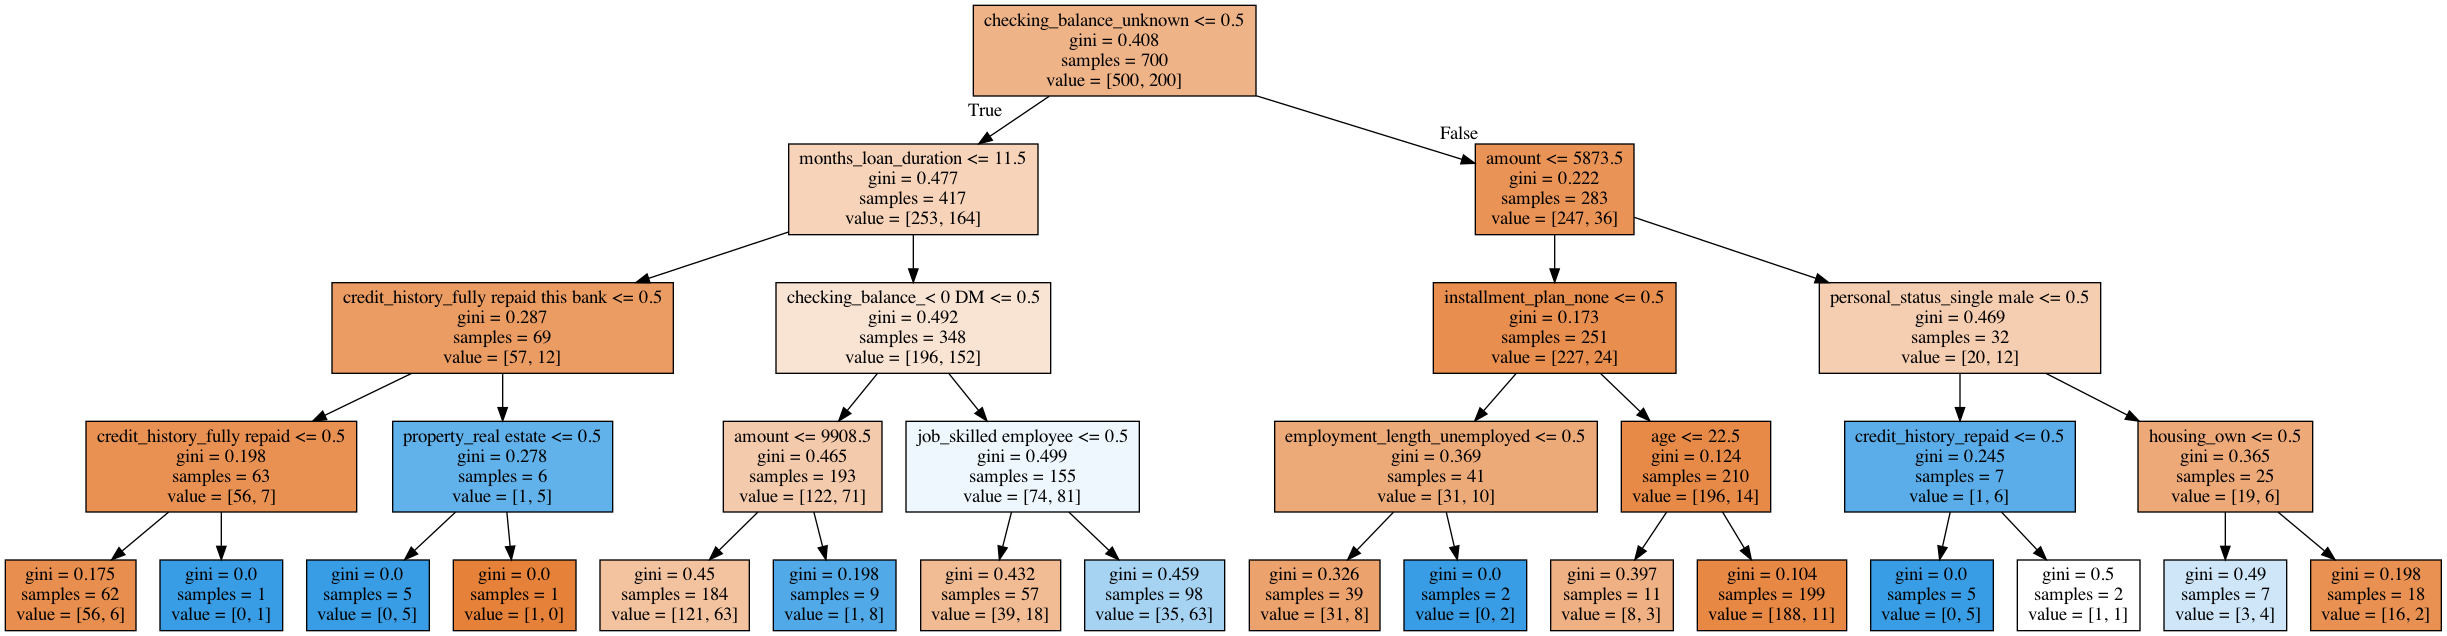

In [104]:
Image.open("tree.png")

In [107]:
a = pd.DataFrame({"feature": X.columns, "importance": est.feature_importances_})
a.sort_values("importance", ascending = False)

,feature,importance
9,checking_balance_unknown,0.319309
1,amount,0.127824
0,months_loan_duration,0.106449
45,job_skilled employee,0.103138
12,credit_history_fully repaid this bank,0.076446
33,personal_status_single male,0.055723
7,checking_balance_< 0 DM,0.055042
30,employment_length_unemployed,0.032157
39,installment_plan_none,0.028827
41,housing_own,0.028571


In [110]:
target = "default"
X = df.drop(columns = target)
X = pd.get_dummies(X, drop_first=True)

label_encoder = preprocessing.LabelEncoder()
y = df[target]
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y
, test_size = 0.3, random_state = 123)


pipe = pipeline.Pipeline([
    #("poly", preprocessing.PolynomialFeatures(degree=1, include_bias=False)),
    #("scaler", preprocessing.StandardScaler()),
    ("est", ensemble.RandomForestClassifier(max_depth=6, n_estimators = 100, max_features=0.7))
])

pipe.fit(X_train, y_train) # train the model

y_train_pred = pipe.predict(X_train)

y_test_pred = pipe.predict(X_test)


#print(metrics.classification_report(y_test, y_test_pred))

print("train accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

train accuracy:  0.8857142857142857
test accuracy:  0.7533333333333333
